In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU, Conv2D, MaxPool2D, GlobalAvgPool2D , RandomFlip ,RandomRotation, RandomZoom , SpatialDropout2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.datasets import mnist , fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import load_iris , make_classification
from tensorflow.keras.utils import to_categorical , image_dataset_from_directory
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
DATASET_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"

CSV_PATH = os.path.join(DATASET_PATH, "styles.csv")
IMAGE_PATH = os.path.join(DATASET_PATH, "images")

df = pd.read_csv(csv_path, on_bad_lines="skip")
df.head(5)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [8]:
df["filepath"] = df["id"].astype(str) + ".jpg"
df["filepath"] = df["filepath"].apply(
    lambda x: os.path.join(IMAGE_PATH, x)
)
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)
print(df.shape)

(44419, 11)


In [9]:
counts = df["masterCategory"].value_counts() 
valid_classes = counts[counts >= 2].index
df = df[df["masterCategory"].isin(valid_classes)].reset_index(drop=True)


In [11]:
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["masterCategory"])
print("Classes:")
print(encoder.classes_) 
print("\nNumber of Classes:", len(encoder.classes_))

Classes:
['Accessories' 'Apparel' 'Footwear' 'Free Items' 'Personal Care'
 'Sporting Goods']

Number of Classes: 6


In [12]:
train_df, test_df = train_test_split(
    df,    test_size=0.20,
    stratify=df["label"],
    random_state=42 )
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42 )
print("Training   :", len(train_df))
print("Validation :", len(valid_df))
print("Testing    :", len(test_df))

Training   : 28427
Validation : 7107
Testing    : 8884


In [13]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = image / 255.0
    return image, label

In [14]:
train_ds = tf.data.Dataset.from_tensor_slices(    
    (        train_df["filepath"].values,
             train_df["label"].values    ) )
valid_ds = tf.data.Dataset.from_tensor_slices(    
    (        valid_df["filepath"].values,
             valid_df["label"].values    ) ) 
test_ds = tf.data.Dataset.from_tensor_slices(    
    (        test_df["filepath"].values,
             test_df["label"].values    ) )

I0000 00:00:1784527841.725413      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784527841.728511      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [15]:
train_ds = (    
    train_ds    
    .map(load_image)    
    .batch(32)    
    .prefetch(tf.data.AUTOTUNE) ) 
valid_ds = (    
    valid_ds    
    .map(load_image)    
    .batch(32)    
    .prefetch(tf.data.AUTOTUNE) )
test_ds = (
    test_ds    
    .map(load_image)    
    .batch(32)    
    .prefetch(tf.data.AUTOTUNE) )

In [18]:
from tensorflow.keras import layers
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 
AUTOTUNE = tf.data.AUTOTUNE 
data_augmentation = tf.keras.Sequential(
    [layers.RandomFlip("horizontal"),
     layers.RandomRotation(0.05),
     layers.RandomZoom(0.10), ])

In [22]:
from tensorflow.keras.layers import MaxPooling2D,GlobalAveragePooling2D
model = Sequential([
    Input(shape=(*IMG_SIZE, 3)),

    # Block 1
    Conv2D(32, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Conv2D(32, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Conv2D(64, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),
    Dropout(0.30),

    # Block 3
    Conv2D(128, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Conv2D(128, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),
    Dropout(0.35),

    # Block 4
    Conv2D(256, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Conv2D(256, (3,3), padding="same", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    GlobalAveragePooling2D(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(6, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 56, 56, 128)    │             

 Total params: 1,440,550 (5.50 MB)

 Trainable params: 1,438,630 (5.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


2026-07-20 06:14:36.089864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:14:36.243822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:14:39.002294: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:14:39.305403: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1784528091.581567     281 device_compiler.h:196]

888/889 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6874 - loss: 0.8850

2026-07-20 06:17:14.144492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:17:14.293023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:17:15.594521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:17:15.894164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-20 06:17:16.080830: E external/local_xla/xla/service

889/889 ━━━━━━━━━━━━━━━━━━━━ 196s 187ms/step - accuracy: 0.7827 - loss: 0.6551 - val_accuracy: 0.8551 - val_loss: 0.4853 - learning_rate: 1.0000e-04
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 150s 168ms/step - accuracy: 0.9132 - loss: 0.3460 - val_accuracy: 0.9216 - val_loss: 0.3079 - learning_rate: 1.0000e-04
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 149s 168ms/step - accuracy: 0.9402 - loss: 0.2704 - val_accuracy: 0.9371 - val_loss: 0.2838 - learning_rate: 1.0000e-04
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 149s 168ms/step - accuracy: 0.9521 - loss: 0.2325 - val_accuracy: 0.9316 - val_loss: 0.2866 - learning_rate: 1.0000e-04
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 149s 168ms/step - accuracy: 0.9611 - loss: 0.2075 - val_accuracy: 0.8898 - val_loss: 0.5595 - learning_rate: 1.0000e-04
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 150s 168ms/step - accuracy: 0.9724 - loss: 0.1749 - val_accuracy: 0.9668 - val_loss: 0.1952 - learning_rate: 2.0000e-05
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 150s 168ms/

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")

In [32]:
y_true = [] 
y_pred = [] 
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
from sklearn.metrics import classification_report 
print(   
    classification_report(
        y_true,        
        y_pred,        
        target_names=encoder.classes_    ) )

                precision    recall  f1-score   support

   Accessories       0.94      0.97      0.95      2255
       Apparel       0.99      0.97      0.98      4278
      Footwear       1.00      0.99      0.99      1844
    Free Items       0.00      0.00      0.00        21
 Personal Care       0.92      0.99      0.95       481
Sporting Goods       0.00      0.00      0.00         5

      accuracy                           0.97      8884
     macro avg       0.64      0.65      0.65      8884
  weighted avg       0.97      0.97      0.97      8884



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


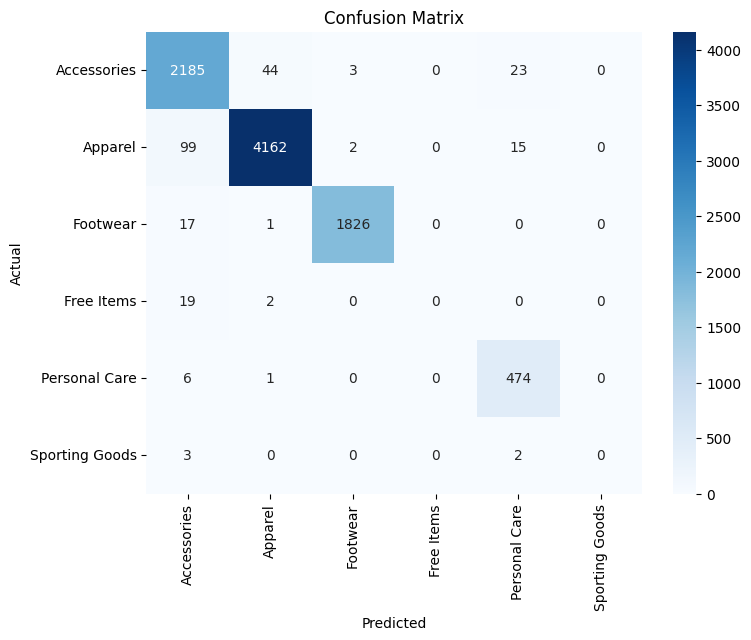

In [34]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap( 
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_ )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix") 
plt.show()